# Portfolio Part 3 - Analysis of Loan Approval Data (2024 S2)

In [301]:
your_name = "Tuan Dat Nguyen"
your_student_id = "46233148"

## Task background
In this Portfolio task, you will work on a new dataset named 'Loan Approval' which is a modified version from a synthetic Dataset for Risk Assessment and Loan Approval Modeling (many thanks to LORENZO ZOPPELLETTO for the sharing of this dataset). This dataset comprises 20,000 records of personal and financial data, designed to facilitate the development of predictive models for risk assessment and loan approval. In this portfolio part, you are mainly required to train classification models to determine the outcome of loan approval, indicating whether an applicant is likely to be approved or denied for a loan.

The dataset includes diverse features such as demographic information, credit history, employment status, income levels, existing debt, and other relevant financial metrics, providing a comprehensive foundation for sophisticated data-driven analysis and decision-making.

The dataset includes the following columns:

|Column|Meaning|
|:-----|:-----|
|ApplicationDate| Loan application date|
|Age| Applicant's age|
|AnnualIncome| Yearly income|
|CreditScore| Creditworthiness score|
|EmploymentStatus| Job situation|
|EducationLevel| Highest education attained|
|Experience| Work experience|
|LoanAmount| Requested loan size|
|LoanDuration| Loan repayment period|
|MaritalStatus| Applicant's marital state|
|NumberOfDependents| Number of dependents|
|HomeOwnershipStatus| Homeownership type|
|MonthlyDebtPayments| Monthly debt obligations|
|CreditCardUtilizationRate| Credit card usage percentage|
|NumberOfOpenCreditLines| Active credit lines|
|NumberOfCreditInquiries| Credit checks count|
|DebtToIncomeRatio| Debt to income proportion|
|BankruptcyHistory| Bankruptcy records|
|LoanPurpose| Reason for loan|
|PreviousLoanDefaults| Prior loan defaults|
|PaymentHistory| Past payment behavior|
|LengthOfCreditHistory| Credit history duration|
|SavingsAccountBalance| Savings account amount|
|CheckingAccountBalance| Checking account funds|
|TotalAssets| Total owned assets|
|TotalLiabilities| Total owed debts|
|MonthlyIncome| Income per month|
|UtilityBillsPaymentHistory| Utility payment record|
|JobTenure| Job duration|
|NetWorth| Total financial worth|
|BaseInterestRate| Starting interest rate|
|InterestRate| Applied interest rate|
|MonthlyLoanPayment| Monthly loan payment|
|TotalDebtToIncomeRatio| Total debt against income|
|LoanApproved| Loan approval status|
|RiskScore| Risk assessment score|

## Task Description
Your high level goal in this notebook is to build and evaluate predictive models for 'loan approval' from other available features. More specifically, you need to complete the following major tasks:

1. Clean and preprocess the dataset for the downstream data analysis tasks.

2. Build and evaluate logistic regression models with this datasets.

3. Build and evaluate KNN models with this datasets.

Note 1: While the main steps of each task have been given with the requirements, you should learn how to properly organise and comment your notebook by yourself to ensure that your notebook file is professional and readable.

Note 2: You will be evaluated on the accuracy of the model, the process that you produce the results,  and your clear description and justification of your implementation. So, try your best to comment your source code to showing your understanding and critical thinking.


## Load the dataset and show the basic information

In [303]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Turn off the warning
import warnings
warnings.filterwarnings('ignore')

#Import the dataset and show the first 5 rows of the data
data = pd.read_csv('loan_approval.csv')
data.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45.0,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,NaN
1,2018-01-02,38.0,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47.0,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,NaN
3,2018-01-04,58.0,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,NaN
4,2018-01-05,37.0,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,NaN


In [304]:
#Provide a rough picture of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         19900 non-null  float64
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               19900 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [305]:
#Describe the dataset for each particular column
data.describe(include="all")

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000,19900.000000,20000.000000,20000.000000,20000,20000,20000.000000,20000.000000,20000.000000,19900,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,1000.000000
unique,20000,NaN,NaN,NaN,3,5,NaN,NaN,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2018-01-01,NaN,NaN,NaN,Employed,Bachelor,NaN,NaN,NaN,Married,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,17036,6054,NaN,NaN,NaN,9999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,39.751759,59161.473550,571.612400,NaN,NaN,17.522750,24882.867800,54.057000,NaN,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.687600
std,NaN,11.630809,40350.845168,50.997358,NaN,NaN,11.316836,13427.421217,24.664857,NaN,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.881033
min,NaN,18.000000,15000.000000,343.000000,NaN,NaN,0.000000,3674.000000,12.000000,NaN,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,30.400000
25%,NaN,31.750000,31679.000000,540.000000,NaN,NaN,9.000000,15575.000000,36.000000,NaN,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,NaN,40.000000,48566.000000,578.000000,NaN,NaN,17.000000,21914.500000,48.000000,NaN,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,NaN,48.000000,74391.000000,609.000000,NaN,NaN,25.000000,30835.000000,72.000000,NaN,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000


## Task 1: Clean the datasets (10 marks)

### Step 1.1 Handle the missing values with following rules (5 marks)
1. If over 50% of the values of a column, the column should be removed from the data frame; 
2. For a categorical column, if a row contains a missing value, you need to delete the whole row; 
3. For a numerical column, if a row contains a missing value, you need to perform a missing value imputation with the average value of the column.

**[1.1.1] Remove columns in the dataset that contain over 50% of missing values**

In [309]:
data = data.dropna(thresh = 0.5*len(data), axis = 1) #axis equals to 1 means removing the columns that meet the threshold

#Show the new information of the data after removing those above values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         19900 non-null  float64
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               19900 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

**Comment**: Based on the information of both the raw dataset and this one, the column `RiskScore` has been removed since it has over 50% of missing values.

**[1.1.2] Remove rows in the categorical columns that contain missing values**

In [312]:
#Define categorical columns
categorical_columns = ['ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

#Remove rows in these categorical columns that do not have any values
data = data.dropna(subset = categorical_columns)
#Provide new information of the dataset after the removal
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19900 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             19900 non-null  object 
 1   Age                         19800 non-null  float64
 2   AnnualIncome                19900 non-null  int64  
 3   CreditScore                 19900 non-null  int64  
 4   EmploymentStatus            19900 non-null  object 
 5   EducationLevel              19900 non-null  object 
 6   Experience                  19900 non-null  int64  
 7   LoanAmount                  19900 non-null  int64  
 8   LoanDuration                19900 non-null  int64  
 9   MaritalStatus               19900 non-null  object 
 10  NumberOfDependents          19900 non-null  int64  
 11  HomeOwnershipStatus         19900 non-null  object 
 12  MonthlyDebtPayments         19900 non-null  int64  
 13  CreditCardUtilizationRate   19900 no

**Comment**: Based on the information above, it can be seen that almost all columns now have 19900 non-null values, apart from the `Age`, which is a numerical column, as it contains less than 100 rows compared to the rest. 

**[1.1.3] Replace all the missing values in the numerical columns by imputating with the average value of the column** 

In [315]:
#Define all numerical columns by dropping the already-identified categorical columns
numerical_columns = data.drop(columns = categorical_columns).columns

#Replace the missing values in the column with a mean value of that column
for column in numerical_columns:
    data[column]. fillna(data[column].mean(), inplace = True)

#Read the new information and show the first few rows of the dataset
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 19900 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             19900 non-null  object 
 1   Age                         19900 non-null  float64
 2   AnnualIncome                19900 non-null  int64  
 3   CreditScore                 19900 non-null  int64  
 4   EmploymentStatus            19900 non-null  object 
 5   EducationLevel              19900 non-null  object 
 6   Experience                  19900 non-null  int64  
 7   LoanAmount                  19900 non-null  int64  
 8   LoanDuration                19900 non-null  int64  
 9   MaritalStatus               19900 non-null  object 
 10  NumberOfDependents          19900 non-null  int64  
 11  HomeOwnershipStatus         19900 non-null  object 
 12  MonthlyDebtPayments         19900 non-null  int64  
 13  CreditCardUtilizationRate   19900 no

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2018-01-01,45.0,39948,617,Employed,Master,22,13152,48,Married,...,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0
1,2018-01-02,38.0,39709,628,Employed,Associate,15,26045,48,Single,...,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0
2,2018-01-03,47.0,40724,570,Employed,Bachelor,26,17627,36,Married,...,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0
3,2018-01-04,58.0,69084,545,Employed,High School,34,37898,96,Single,...,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0
4,2018-01-05,37.0,103264,594,Employed,Associate,17,9184,36,Married,...,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1


**Comment:** After handling all the missing values and replacing with the average value for numerical columns, all remaining columns ahave the same number of non-null values, which is 19900.

### Step 1.2 Handle categorical attributes (5 marks)
1. If all the categorical values of a column are unique, this column does not provide any statistical informaiton and should be deleted.
2. Use one hot encoding to convert the categorical values into numerical ones.

**[1.2.1] Delete catgorical values of a column**

In [319]:
#Define categorical columns that have unique values

unique_counts = data[categorical_columns].nunique()
print(unique_counts)

ApplicationDate        19900
EmploymentStatus           3
EducationLevel             5
MaritalStatus              4
HomeOwnershipStatus        4
LoanPurpose                5
dtype: int64


In [320]:
#Determine which of the above categorical columns have unique values
#If the number of rows in a column is equal to the length of the data, meaning that all the data of that column is unique
total_rows = len(data)
unique_columns = unique_counts[unique_counts == total_rows].index.tolist()
unique_columns

['ApplicationDate']

In [321]:
#Remove that column having all unique data values
data_new = data.drop(columns = unique_columns)
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19900 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         19900 non-null  float64
 1   AnnualIncome                19900 non-null  int64  
 2   CreditScore                 19900 non-null  int64  
 3   EmploymentStatus            19900 non-null  object 
 4   EducationLevel              19900 non-null  object 
 5   Experience                  19900 non-null  int64  
 6   LoanAmount                  19900 non-null  int64  
 7   LoanDuration                19900 non-null  int64  
 8   MaritalStatus               19900 non-null  object 
 9   NumberOfDependents          19900 non-null  int64  
 10  HomeOwnershipStatus         19900 non-null  object 
 11  MonthlyDebtPayments         19900 non-null  int64  
 12  CreditCardUtilizationRate   19900 non-null  float64
 13  NumberOfOpenCreditLines     19900 no

**Comment**: The above information shows that only the `Application Date` column has all unique values. Thus, it has been removed. In total, the data now has 34 attributes.

**[1.2.2] Convert categorical values into numerical ones using One Hot Encoding**

In [324]:
#Define an updated list of categorical columns
categorical_columns = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

#Apply One Hot Encoding technique
df = pd.get_dummies(data_new, columns = categorical_columns)

#The encoding process uses boolean values to represent the presence of such a feature
#Determine which columns are boolean
converted_col = df.select_dtypes(include = 'bool').columns

#using astype to transform each unique category in categorical columns into new binary features (changing to 0 and 1 - integer)
df[converted_col] = df[converted_col].astype(int)

#Display the dataset after applying One Hot Encoding
df.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Widowed,HomeOwnershipStatus_Mortgage,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,45.0,39948,617,22,13152,48,2,183,0.354418,1,...,0,0,0,1,0,0,0,0,1,0
1,38.0,39709,628,15,26045,48,1,496,0.087827,5,...,0,1,0,0,0,0,1,0,0,0
2,47.0,40724,570,26,17627,36,2,902,0.137414,2,...,0,0,0,0,1,0,0,1,0,0
3,58.0,69084,545,34,37898,96,1,755,0.267587,2,...,0,1,0,0,0,0,0,0,1,0
4,37.0,103264,594,17,9184,36,1,274,0.320535,0,...,0,1,0,0,0,0,1,0,0,0


In [325]:
#Show the new information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19900 entries, 0 to 19999
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             19900 non-null  float64
 1   AnnualIncome                    19900 non-null  int64  
 2   CreditScore                     19900 non-null  int64  
 3   Experience                      19900 non-null  int64  
 4   LoanAmount                      19900 non-null  int64  
 5   LoanDuration                    19900 non-null  int64  
 6   NumberOfDependents              19900 non-null  int64  
 7   MonthlyDebtPayments             19900 non-null  int64  
 8   CreditCardUtilizationRate       19900 non-null  float64
 9   NumberOfOpenCreditLines         19900 non-null  int64  
 10  NumberOfCreditInquiries         19900 non-null  int64  
 11  DebtToIncomeRatio               19900 non-null  float64
 12  BankruptcyHistory               19900

**Comment**: After handling categorical attributes using `One Hot Encoding` technique, there are now total of 50 columns, each has 19900 values.

## Task 2: Build a logistic regression classification model (25 marks)

### Step 2.1 Specify the features and the label, and split the dataset into training data and testing data (5 marks)
1. The attirbute "LoanApproved" is the label, which is the prediction target. The remaining attributes are the features.
2. The ratio for splitting the dataset is 80% for training and 20% for testing. Note that you need to set the "random_state" parameter as your student ID to produce your personlised splitting. Failing to do so will lose marks.

In [329]:
#Specify features and label
X = df.drop(columns = ['LoanApproved'])
y = df['LoanApproved']

#Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 46233148)

#Display training and testing data set
print("The shape of training data is:", X_train.shape, y_train.shape)
print("The shape of testing data is:", X_test.shape, y_test.shape)

The shape of training data is: (15920, 49) (15920,)
The shape of testing data is: (3980, 49) (3980,)


**Comment**: After splitting the data
- The training set of remaining attributes X_train has 15920 rows and 49 columns, while the target label `LoanApproved`, represented as y_train, has 15920 values corresponding to each respective row in the training example X_train. This indicates that the model learns from these 15920 examples using 49 features to predict the label. 
- The testing set of remaining attributes X_test has 3980 rows and the same number of feature columns (49). Similarly, the corresponding y_test has that number of rows as its respective X_test, representing the actual outcome of loan approval.

### Step 2.2 Build a logistic regression model (10 marks)
1. Train a logistic regression model
2. Report two classification performance metrics (accuracy and f1-score) on the testing data
3. Also report the two metrics on the training data, and compare the results with that of the testing data. Make a justification on whether the model is overfitting based on the comparison.

**[2.2.1] Train a logistic regression model**

In [333]:
logreg_model= LogisticRegression()
logreg_model.fit(X_train, y_train)

LogisticRegression()

**[2.2.2] Report two classification performance metrics on the testing data**

In [335]:
#Predict the testing data from the logistic regression model
predicted_test_data = logreg_model.predict(X_test)

#Present two classification performance metrics from the predicted testing data
accuracy_test_data = accuracy_score(y_test, predicted_test_data)
f1_test_data = f1_score(y_test, predicted_test_data)

#Display these metrics
print("Accuracy on testing data is:", accuracy_test_data)
print("F1-score on testing data is:", f1_test_data)

Accuracy on testing data is: 0.8957286432160804
F1-score on testing data is: 0.7716015410016511


**[2.2.3] Similarly, report the two metrics on the training data**

In [337]:
#Predict the testing data
predicted_train_data = logreg_model.predict(X_train)

#Report two classification performance metrics
accuracy_train_data = accuracy_score(y_train, predicted_train_data)
f1_train_data = f1_score(y_train, predicted_train_data)

#Display these metrics
print("Accuracy on training data is:", accuracy_train_data)
print("F1-score on training data is:", f1_train_data)

Accuracy on training data is: 0.8887562814070352
F1-score on training data is: 0.7530330497838517


**Comment:** The above results from two classification performance metrics show that
1. `Accuracy`:
   - The model achieves approximately 89.57% accuracy on testing data and 88.88% on the training data.
   - With a small difference of 0.67% between these two elements, it suggests that the model is performing pretty consistently on both sets of data, meaning that it is not overfitting. Therefore, it can be concluded that the model generalises well on unseen data for this metric. 
2. `F1-Score`:
    - The outcome of testing data for the F1-score (0.7716) is slightly higher than that of training data (0.7530).
    - Since these two results are pretty close, this indicates that the model performs quite well, although it might not be perfectly balanced in handling variances.
  
Overall, **the model is not overfitting** as there is no large discrepancy between training and testing metrics (high accuracy and f1-score on training data but much lower on testing data). This positive result means that the model learns how to predict underlying patterns in the data well.

### Step 2.3 Perform the recursive feature elimination (RFE) technique to identify the effective features for building the model (10 marks)
1. Visualise the change of the two performance metrics with respect to the number of eliminated features using a line chart.
2. In terms of the visualisation result, select a good value for the number of eliminated features with considering both performance maximisation and feature minimisation (two competing goals). Run the RFE again with the chosen number of eliminated features to obtain the corresponding set of retained features.

**[2.3.1] Visualise the behaviour of two performance metrics regarding eliminated features with a line chart**

In [341]:
#Identify the range of the number of eliminated features
num_features = X_train.shape[1] #Using index 1 for columns

#Define different lists to store respective eliminated features with each corresponding performance metric
eliminating_features = []
accuracy_list = []
f1_list = []

#Perform the RFE technique for different numbers of eliminated features
for feature in range(1, num_features + 1):
    rfe = RFE(logreg_model, n_features_to_select = feature)
    rfe.fit(X_train, y_train)

#Predict the testing data
    predicted = rfe.predict(X_test)

#Report two classification performance metrics
    accuracy = accuracy_score(y_test, predicted)
    f1 = f1_score(y_test, predicted)

#Store the metrics results into respective lists
    eliminating_features.append(num_features - feature)
    accuracy_list.append(accuracy)
    f1_list.append(f1)

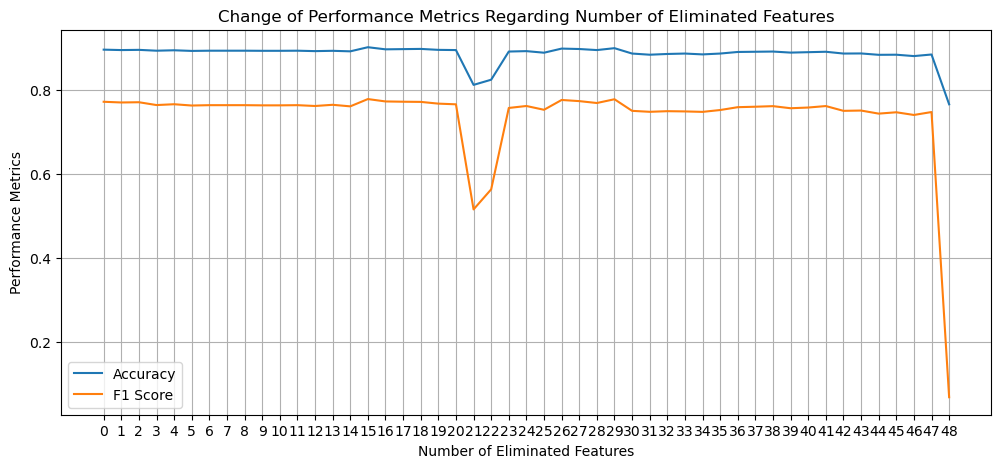

In [342]:
#Visualise the performance of two parameters in regards to the number of eliminated features
plt.figure(figsize=(12,5))
plt.plot(eliminating_features, accuracy_list, label = 'Accuracy')
plt.plot(eliminating_features, f1_list, label = 'F1 Score')
plt.xticks(eliminating_features)
plt.xlabel('Number of Eliminated Features')
plt.ylabel('Performance Metrics')
plt.title('Change of Performance Metrics Regarding Number of Eliminated Features')
plt.grid(True)
plt.legend()
plt.show()

**Comment**:  With respect to the use of RFE technique with logistic regression to eliminate less important features iteratively, the chart above suggests that:
- The blue line represents the change in the `Accuracy` of the testing data, which remains relatively stably high for most of the features. However, it dropped sharply after eliminating 20 features, then recovered from the 23rd feature before another slight drop at the 47th feature.
- Similarly, the `F1-score` (in orange) does not fluctuate much until the 20th feature is eliminated, showing a significant dip before increasingly recovering, even not reaching its previous peak. Both metrics show a plummet when nearly all features have been eliminated at the 47th one.
- Considering two competing goals, which are performance maximisation and feature minimisation, to relatively maintain high performance while eliminating unnecessary features, **the optimal number of eliminated features is 20** as at that point, it gives a reasonably good balance where:
    1. `Accuracy` is close to its maximum (0.88)
    2. `F1-score` remains high and consistent with its peak (0.77)

Therefore, keeping the number of eliminated features at 20 is a good value to ensure both metrics perform well without sacrificing much performance.

**[2.3.2] Based on the above result, perform RFE technique with the chosen number of eliminated features with respect to the retained features** 

In [345]:
#Define the best value that maximises performance and minimises features
best_num_eliminated_features = 20

#Perform the RFE technique with the chosen number of eliminated features
rfe = RFE(logreg_model, n_features_to_select = num_features - best_num_eliminated_features)
rfe.fit(X_train, y_train)

#Define the retained features
retained_features = X_train.columns[rfe.support_] 
#rfe.support_ is a boolean mask to define which features were selected as the most important ones 
retained_features

Index(['Age', 'Experience', 'LoanDuration', 'NumberOfDependents',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults',
       'PaymentHistory', 'LengthOfCreditHistory', 'MonthlyIncome',
       'UtilityBillsPaymentHistory', 'JobTenure', 'BaseInterestRate',
       'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio',
       'EmploymentStatus_Unemployed', 'EducationLevel_Associate',
       'EducationLevel_Doctorate', 'EducationLevel_High School',
       'EducationLevel_Master', 'MaritalStatus_Married',
       'HomeOwnershipStatus_Other', 'HomeOwnershipStatus_Rent',
       'LoanPurpose_Home'],
      dtype='object')

**Comment**: After selecting the optimal number of features to be eliminated (20), retained features now sit at 29 in total.

## Task 3: Build a KNN classification model (25 marks)

### Step 3.1 Build 1-NN classifier (5 marks)
1. Select the features identified in Step 2.3 for this task
2. Buid 1-NN classifier and report two classification performance metrics (accuracy and f1-score) on the testing data
3. Also report the two metrics on the training data, and compare the results with that of the testing data. Make a justification on whether the model is overfitting based on the comparison.

In [349]:
#Define train and test data for the KNN model based on retained features
X_train_KNN = X_train[retained_features]
X_test_KNN = X_test[retained_features]

#Build a 1-NN Classifier
model_1NN = KNeighborsClassifier(n_neighbors = 1) #set k equals to 1 for 1-NN classifier
model_1NN.fit(X_train_KNN, y_train)

KNeighborsClassifier(n_neighbors=1)

**[3.1.1] Report two classfication performance metrics on testing data from 1NN classifier model**

In [351]:
#Predict testing data
predicted_test_1NN = model_1NN.predict(X_test_KNN)

#Calculate the classification performance metrics
accuracy_test_1NN = accuracy_score(y_test, predicted_test_1NN)
f1_test_1NN = f1_score(y_test, predicted_test_1NN)

#Display the above metrics on testing data
print("Accuracy of 1-NN classifier on testing data:", accuracy_test_1NN)
print("F1-score of 1-NN classifier on testing data:", f1_test_1NN)

Accuracy of 1-NN classifier on testing data: 0.8173366834170854
F1-score of 1-NN classifier on testing data: 0.6300254452926208


**[3.1.2] Similarly, report two metrics on the training data from 1NN Classifier model**

In [353]:
#Predict training data
predicted_train_KNN = model_1NN.predict(X_train_KNN)

#Calculate the classification performance metrics
accuracy_train_1NN = accuracy_score(y_train, predicted_train_KNN)
f1_train_1NN = f1_score(y_train, predicted_train_KNN)

#Display the classification performance metrics on testing data
print("Accuracy of 1-NN model on training data:", accuracy_train_1NN)
print("F1-score of 1-NN model on training data:", f1_train_1NN)

Accuracy of 1-NN model on training data: 1.0
F1-score of 1-NN model on training data: 1.0


**Comment:** The results shown on two performance parameters for training and testing data of retained features highlight that:
- The `1NN classifier model` performs its prediction perfectly on training data as both accuracy and F1 score achieve 100%. This also suggests this model has memorised the training set. This is because such a prediction is based on the single closest data point (by one nearest neighbour).
- On the other hand, the testing data sees a drop in both accuracy and F1 scores. The former metric sits at 81.73%, although it is a pretty reasonable number. However, it is still much lower than the perfect accuracy score of training data. Meanwhile, the latter metric is only 0.63, which is significantly lower than the accuracy. This indicates that the `1NN classifier model` struggles to generalize unseen data.

From this, it can be concluded that the **`1NN model` is overfitting** as it performs extremely well on the training data but poorly on the testing data. Indeed, instead of learning patterns from the train data to apply to new data, this model remembers every variance and misclassifies those points, given how highly sensitive the classifier is close to its neighbours.

Increasing the value of K should be considered to reduce overfitting and smooth out predictions to perform better on those two metrics.

### Step 3.2 Use the grid search and cross validation techniques to study the performance change with respect to the hyperparameter K (10 marks)
1. Use grid search to search K in the range (1, 30) both inclusive with 5-fold cross validation. The performance metric used for search is accuracy.
2. Visualise the performance change with respect to K using a line chart. Report the two performance metrics for the best case.

**[3.2.1] Implement grid search for K in range (1,30) inclusively with 5-fold cross validation using accuracy metric**

In [357]:
#Identify the range of K
grid_parameter = {'n_neighbors': range(1,31)} #K runs from 1 to 30 inclusively

#Initialise the KNN model
model_KNN = KNeighborsClassifier()

#Perform grid search with 5-fold cross-validation 
#cross-validation is used to test on different subsets of data
grid_search = GridSearchCV(model_KNN, grid_parameter, cv = 5, scoring = 'accuracy') #set cross-validation parameters to 5
grid_search.fit(X_train_KNN, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 31)}, scoring='accuracy')

In [358]:
#Obtain mean test scores from the grid search results
mean_test_scores = grid_search.cv_results_['mean_test_score']

**[3.2.2] Visualise the performance of accuracy metric in regards to K values using a line chart**

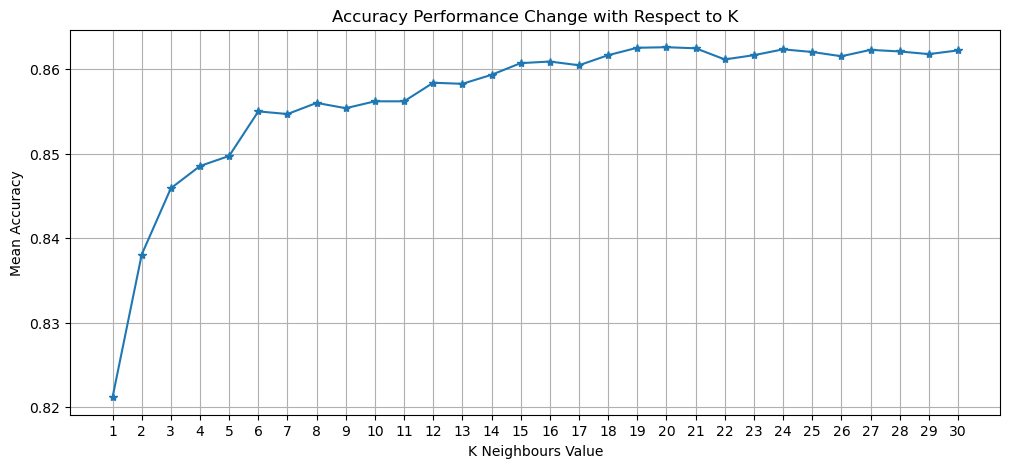

In [360]:
#Plot the performance change regarding K
plt.figure(figsize=(12,5))
plt.plot(grid_parameter['n_neighbors'], mean_test_scores, marker = '*')
plt.xticks(grid_parameter['n_neighbors'])
plt.xlabel('K Neighbours Value')
plt.ylabel('Mean Accuracy')
plt.title('Accuracy Performance Change with Respect to K')
plt.grid(True)
plt.show()

**Comment**: The line chart representing performance change of accuracy metrics with respect to K neighbours value using grid search and cross validation suggests that:
- K = 1, also known as the 1NN classifier model, is the lowest point, with an accuracy rate of around 0.82, as discussed previously.
- As K neighbours' values increase, the accuracy metric rapidly improves and becomes more stabilised, reaching its peak **from the range of 18 to 20**. This highlights that the model starts to generalise better since it considers more neighbours for predictions, with less sensitivity to outlier variances and more balanced biases. It also proves the prior recommendation to use larger values of K for fine-grained, consistent forecasting.
- Although there is a slight fluctuation from K = 20 onwards, the accuracy remains between 0.86 and 0.863. This also indicates that increasing K further would lead to significant performance gains, as the model might smooth out the data too much, leading to less accurate distinctions.

**[3.2.3] Report two classification performance metrics for best case of K**

In [363]:
#Identify the best K
best_K = grid_search.best_params_['n_neighbors']
best_accuracy = grid_search.best_score_

#Train the model with the best K
optimal_model_KNN = KNeighborsClassifier(n_neighbors = best_K)
optimal_model_KNN.fit(X_train_KNN, y_train)

#Predict the testing data
predicted_test_best_KNN = optimal_model_KNN.predict(X_test_KNN)

#Calculate the performance metrics on the testing data
best_accuracy_test = accuracy_score(y_test, predicted_test_best_KNN)
best_f1_test = f1_score(y_test, predicted_test_best_KNN)

#Display the results
print("Best K:", best_K)
print("Accuracy of the testing data with best K is", best_accuracy_test)
print("F1-score of the testing data with best K is", best_f1_test)

Best K: 20
Accuracy of the testing data with best K is 0.8628140703517588
F1-score of the testing data with best K is 0.689419795221843


**Comment**: These results align with the above justification, as it returns **the best value of K is 20** (similar to what can be observed from the chart), with the accuracy and F1-score of roughly 0.863 and 0.689 respectively.

### Step 3.3 Study how the distance metrics affect the model performance (10 marks)
1. Change the distance metric parameter to 3 distance types: 'euclidean'(also l2), 'l1', and 'cosine', respectively, and visualise the model performance with these 3 distances, using a bar chart for both accuracy and f1 scores.
2. Compare the performance metrics, which is the best? Which is the worst?

**[3.3.1] Using 3 distance parameters to evaluate the KNN model's performance**

In [367]:
#Identify the list of distance metrics
distance_params = ['euclidean', 'l1', 'cosine']

#Initialise the model applied to the best K value from the above distance types
for types in distance_params:
    model_KNN = KNeighborsClassifier(n_neighbors = best_K, metric = types)
    model_KNN.fit(X_train_KNN, y_train)

    #Predicted the testing data
    predicted_test_distance = model_KNN.predict(X_test_KNN)

    #Calculate the performance metrics
    accuracy_distance = accuracy_score(y_test, predicted_test_distance)
    f1_distance = f1_score(y_test, predicted_test_distance)

    #Store the results in respective variables
    if types == 'euclidean':
        euclidean_accuracy = accuracy_distance
        euclidean_f1 = f1_distance
    elif types == 'l1':
        l1_accuracy = accuracy_distance
        l1_f1 = f1_distance
    elif types == 'cosine':
        cosine_accuracy = accuracy_distance
        cosine_f1 = f1_distance

**[3.3.2] Visualise model performance with 3 distance parameters using a bar chart for both two classification performance metrics**

([0, 1, 2], [Text(0, 0, 'euclidean'), Text(1, 0, 'l1'), Text(2, 0, 'cosine')])

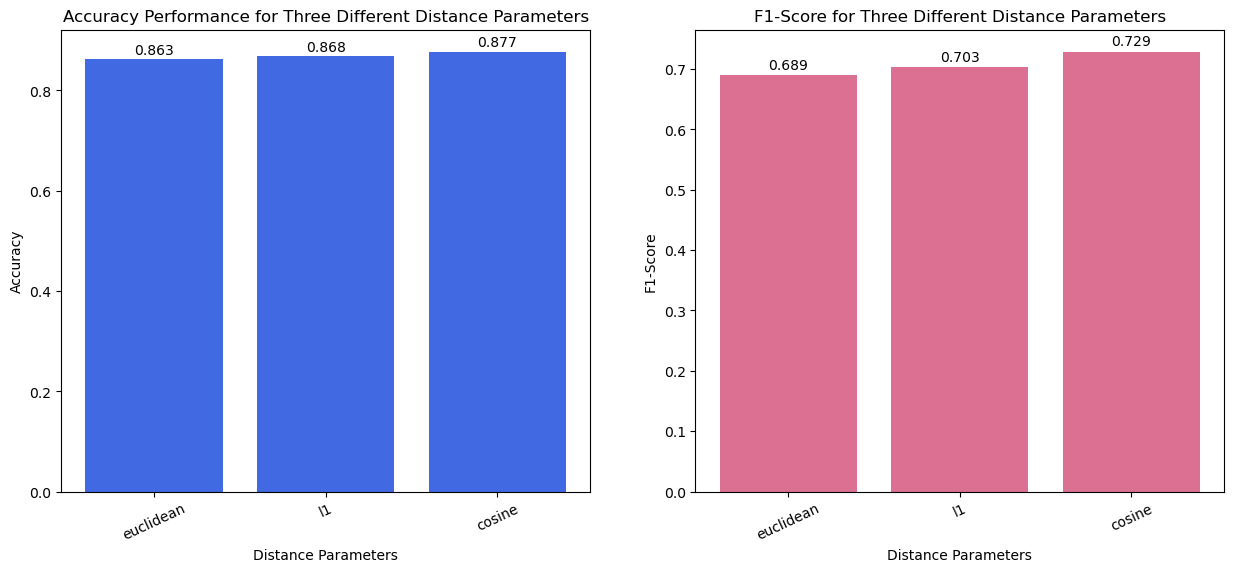

In [369]:
#Set up the plot size
plt.figure(figsize = (15, 6))

#Subplot for accuracy between 3 parameters
plt.subplot(1, 2, 1)
plt.bar(distance_params, [euclidean_accuracy, l1_accuracy, cosine_accuracy], label = 'Accuracy', color = 'royalblue')

#Add numbers on top of the bars
for index, value in enumerate([euclidean_accuracy, l1_accuracy, cosine_accuracy]):
    plt.text(index, value + 0.01, str(round(value, 3)), ha = 'center')

plt.xlabel('Distance Parameters')
plt.ylabel('Accuracy')
plt.title('Accuracy Performance for Three Different Distance Parameters')
plt.xticks(rotation = 25)

#Subplot for F1-score between 3 parameters
plt.subplot(1, 2, 2)
plt.bar(distance_params, [euclidean_f1, l1_f1, cosine_f1], label = 'F1-Score', color = 'palevioletred')

#Add numbers on top of the bars
for index, value in enumerate([euclidean_f1, l1_f1, cosine_f1]):
    plt.text(index, value + 0.01, str(round(value, 3)), ha = 'center')

plt.xlabel('Distance Parameters')
plt.ylabel('F1-Score')
plt.title('F1-Score for Three Different Distance Parameters')
plt.xticks(rotation = 25)

**[3.3.3] Compare performance metrics**

The two charts emphasise the comparison of accuracy and F1-score metrics for three different distance parameters. From this, it can be seen that:
- `Cosine Distance` shows the best performance with the highest accuracy at 0.877 and the F1-score at 0.729. Among the group, it provides the most correct predictions, suggesting a better balance between biases and variances. This proves that this distance parameter appears to be the most effective in capturing underlying patterns and relationships between data points.
- In contrast, the worst performance goes to `Euclidean Distance` as its accuracy and F1-score are the lowest in the group, sitting at 0.863 and 0.689, respectively. Despite being a popular parameter, it is much more affected by variances and also becomes more sensitive to the magnitudes of features (i.e. identifying the distance between data points tends to be similar). This results in the least effective generalising of the datasets in the matter of relative neighbours between data points.

Ultimately, `Cosine Distance` seems to be the most suitable parameter that maximises the performance of predictions and generalisations in this KNN model.